# Lab Sheet 8

In [2]:
from header import *

Exercise 1

Here we define certain polynomials $p_0,\dotsc,p_3$.

In [3]:
x = sp.symbols('x')
p = [
 sp.sqrt(sp.Rational(1/2)),
 sp.sqrt(sp.Rational(3/2)) * x,
 sp.sqrt(sp.Rational(5/8)) * (3*x**2 - 1),
 sp.sqrt(sp.Rational(7/8)) * (5*x**3 - 3*x)
]
for i in range(4):
    display(Latex(f"$p_{i}= {sp.latex(p[i])}$"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We next calculate all the integrals $\int_{-1}^1 p_ip_j\,dx$ for $0\leq i,j<4$, and arrange them into a matrix.  This turns out to be the identity matrix, which means that $\int_{-1}^1 p_ip_j\,dx$ is zero unless $i=j$, in which case it is equal to one.

In [6]:
sp.Matrix([[sp.integrate(p[i] * p[j],(x,-1,1)) for j in range(4)] for i in range(4)])

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

We now want to find a function of the form $p_4=ax^4+bx^2+c$ which makes the above pattern continue.

In [5]:
a,b,c = sp.symbols('a b c')
p4 = a * x**4 + b * x**2 + c
eqs = [sp.integrate(p4 * p[i],(x,-1,1)) for i in range(4)]
display(eqs)
eqs.append(sp.integrate(p4**2, (x,-1,1)) - 1)
sol = sp.solve(eqs)
display(sol)
p4 = p4.subs(sol[1])
p.append(p4)
display(Latex(f"$p_{4}= {sp.latex(p4)}$"))
display(Latex("This matrix of integrals should be the identity matrix"))
sp.Matrix([[sp.integrate(p[i] * p[j],(x,-1,1)) for j in range(5)] for i in range(5)])

[sqrt(2)*a/5 + sqrt(2)*b/3 + sqrt(2)*c,
 0,
 4*sqrt(10)*a/35 + 2*sqrt(10)*b/15,
 0]

[{a: -105*sqrt(2)/16, b: 45*sqrt(2)/8, c: -9*sqrt(2)/16},
 {a: 105*sqrt(2)/16, b: -45*sqrt(2)/8, c: 9*sqrt(2)/16}]

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Matrix([
[1, 0, 0, 0, 0],
[0, 1, 0, 0, 0],
[0, 0, 1, 0, 0],
[0, 0, 0, 1, 0],
[0, 0, 0, 0, 1]])

We now define 
$$ q(n) = \frac{\sqrt{n+1/2}}{2^n(n!)} \,\frac{d^n}{dx^n}((x^2-1)^n) $$

In [6]:
q = lambda n : sp.sqrt(n + sp.Rational(1,2))*sp.diff((x*x-1)**n,x,n)/(2**n * sp.factorial(n))

The cell below checks that $p_n=q(n)$ for $n\leq 4$.  (This is [Rodrigues's formula](https://en.wikipedia.org/wiki/Rodrigues%27_formula#Legendre)).

In [7]:
[sp.simplify(p[i] - q(i)) for i in range(5)]

[0, 0, 0, 0, 0]

In [10]:
del x, p, q

Exercise 2

Here we investigate integrals of the form $J(n,m) = \int x^n\ln(x)^m\,dx$.

In [10]:
x = sp.symbols('x')
def J(n,m):
    return sp.factor(sp.integrate(x **n * sp.log(x)**m, x))

Here are some examples:

In [12]:
display(Latex("$J(3,2) = " + sp.latex(J(3,2)) + "$"))
display(Latex("$J(4,1) = " + sp.latex(J(4,1)) + "$"))
display(Latex("$J(4,3) = " + sp.latex(J(4,3)) + "$"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

The pattern is that $J(n,m)$ is $x^{n+1}$ multiplied by a polynomial of degree $m$ in $\log(x)$.

In [13]:
del x

Exercise 3

In [14]:
x = sp.symbols('x')

Here are some integrals where sympy returns an answer in terms of functions that are not so familiar:
- $\text{erf}(x)$ is the [error function](https://en.wikipedia.org/wiki/Error_function)
- $\text{li}(x)$ is the [logarithmic integral function](https://en.wikipedia.org/wiki/Logarithmic_integral_function)
- $F(x|a)$ is an [elliptic integral](https://en.wikipedia.org/wiki/Elliptic_integral#Incomplete_elliptic_integral_of_the_first_kind)
- $\Gamma(x)$ is the [Gamma function](https://en.wikipedia.org/wiki/Gamma_function)
- ${}_2F_1(a,b,c|x)$ is a [hypergeometric function](https://en.wikipedia.org/wiki/Hypergeometric_function)


In [15]:
sp.integrate(sp.exp(-x*x), x)

sqrt(pi)*erf(x)/2

In [16]:
sp.integrate(1/sp.log(x), x)

li(x)

In [17]:
sp.integrate(1/(sp.sqrt(1-x**2)*sp.sqrt(1-2*x**2)),x)

Piecewise((sqrt(2)*elliptic_f(asin(sqrt(2)*x), 1/2)/2, (x > -sqrt(2)/2) & (x < sqrt(2)/2)))

In [18]:
sp.integrate((x**8+1)**sp.Rational(-1,2),x)

x*gamma(1/8)*hyper((1/8, 1/2), (9/8,), x**8*exp_polar(I*pi))/(8*gamma(9/8))

Here are some examples that sympy cannot integrate, even in terms of obscure special functions like those mentioned above.

In [19]:
sp.integrate(sp.sin(x)*sp.log(sp.log(x)),x)

Integral(log(log(x))*sin(x), x)

In [20]:
sp.integrate(sp.sin(sp.sin(sp.sin(x))),x)

Integral(sin(sin(sin(x))), x)

In [21]:
sp.integrate(1/sp.sqrt(1+x+x**10),x)

Integral(1/sqrt(x**10 + x + 1), x)

The simplest function that sympy cannot integrate is probably $x^x$:

In [22]:
display(sp.integrate(x+3,x))
display(sp.integrate(x*x,x))
display(sp.integrate(2**x,x))
display(sp.integrate(x**x,x))

x**2/2 + 3*x

x**3/3

2**x/log(2)

Integral(x**x, x)

Exercise 4

Here we investigate the functions $y=\sum_{i=0}^3\sin((2i+1)x)/(2i+1)$ and $z=\int y\,dx$.

In [14]:
y = sp.sin(x) + sp.sin(3*x)/3 + sp.sin(5*x)/5 + sp.sin(7*x)/7
z = sp.integrate(y,x)
display(Latex("$y=" + sp.latex(y) + "$"))
display(Latex("$z=\\int y\\,dx=" + sp.latex(z) + "$"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We find that $y$ gives an approximate square wave, and $z$ gives an approximate sawtooth wave.  (These are basic examples from Fourier analysis.  The approximations would be better if we added more terms following the same pattern.)

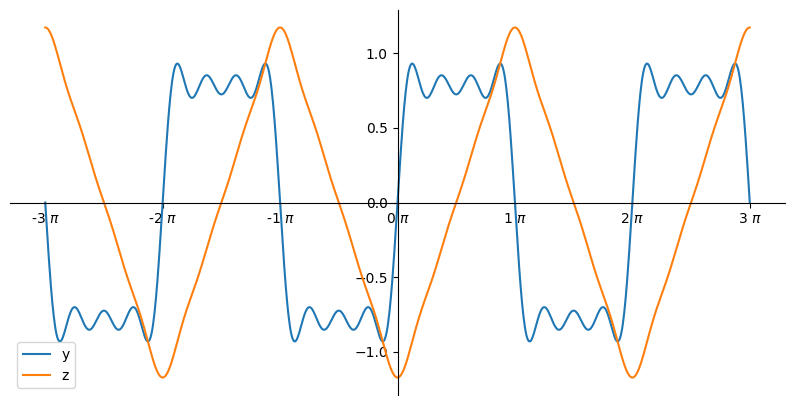

In [24]:
xs = np.linspace(-3*np.pi, 3*np.pi,1000)
ys = sp.lambdify(x,y,'numpy')(xs)
zs = sp.lambdify(x,z,'numpy')(xs)
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(xs/np.pi,ys,label='y')
ax.plot(xs/np.pi,zs,label='z')
fix_axes(ax)
use_pi_ticks(ax)
ax.legend()


In [25]:
del x, y, z

Exercise 5

Here we investigate the functions $y=x\,e^{-x}\sin(20x)$ and $z=20\int y\,dx$.

In [16]:
x = sp.symbols('x')

In [21]:
y = x*sp.sin(20*x)*sp.exp(-x)
z = 20 * sp.integrate(y,x)
display(Latex("$y=" + sp.latex(y) + "$"))
display(Latex("$z=20\\int y\\,dx=" + sp.latex(z) + "$")) 
display(Latex("$\\qquad \\approx " + sp.latex(z.evalf()) + "$"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

The plots below show that the graph of $z$ is close to that of $y$, but shifted forwards by a quarter of a cycle.  This is easy to understand in terms of the above approximate formula for $z$.  Three of the numerical coefficients are small, and the remaining coefficient is close to $-1$, giving 
$$ z\approx -x\,e^{-x}\cos(20x)=x\,e^{-x}\sin(20x-\pi/2). $$

<Axes: >

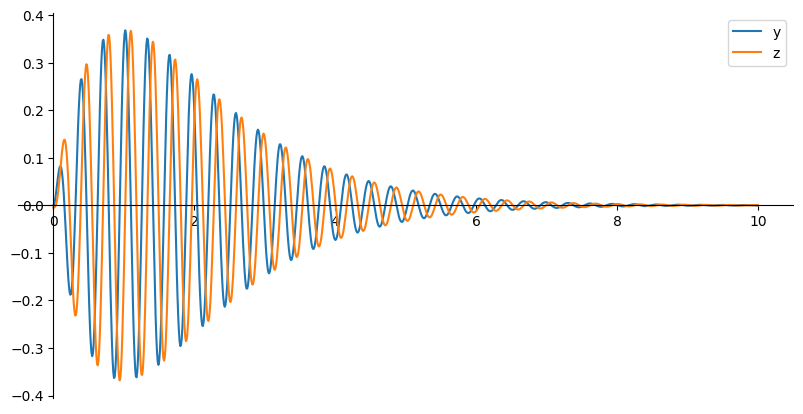

In [18]:
y_fun = sp.lambdify(x,y,'numpy')
z_fun = sp.lambdify(x,z,'numpy')
xs = np.linspace(0,10,1000)
ys = y_fun(xs)
zs = z_fun(xs)
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(xs,ys,label='y')
ax.plot(xs,zs,label='z')
ax.legend()
fix_axes(ax)

<Axes: >

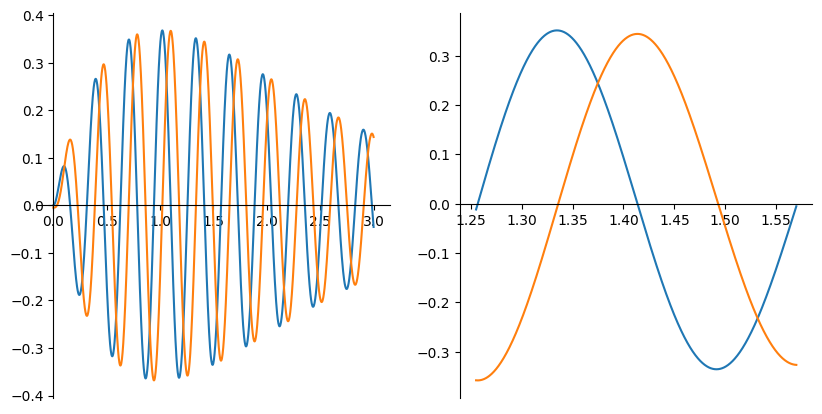

In [31]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
xs = np.linspace(0,3,1000)
ys = y_fun(xs)
zs = z_fun(xs)
ax[0].plot(xs,ys)
ax[0].plot(xs,zs)
fix_axes(ax[0])
xs = np.linspace(1.255,1.57,1000)
ys = y_fun(xs)
zs = z_fun(xs)
ax[1].plot(xs,ys)
ax[1].plot(xs,zs)
fix_axes(ax[1])

We now consider $y^2+z^2$.  In the approximate formula below, the terms $x^2e^{-2x}\sin^2(20x)$ and $x^2e^{-2x}\cos^2(20x)$ both appear with coefficients close to one, while all other coefficients are small.  As $\sin^2(20x)+\cos^2(20x)=1$, this gives $y^2+z^2\approx x^2e^{-2x}$.

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

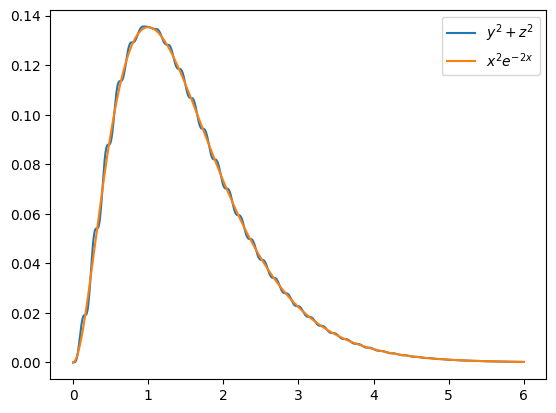

In [24]:
r2 = sp.simplify(y**2 + z**2)
r2_fun = sp.lambdify(x,r2,'numpy')
r2_approx = lambda x : x**2 * np.exp(-2*x)
display(Latex("$y^2+z^2=" + sp.latex(r2) + "$"))
display(Latex("$\\qquad\\approx " + sp.latex(sp.expand(r2.evalf())) + "$"))
xs = np.linspace(0,6,1000)
r2s = r2_fun(xs)
plt.plot(xs, r2s, label='$y^2+z^2$')
plt.plot(xs, r2_approx(xs), label='$x^2 e^{-2x}$')
plt.legend()

In [40]:
del x, y, z, r2

Exercise 6

Here we find a function of the form $y=(ax^2+bx+c)e^{-x}$ such that $\int_{x=0}^\infty x^ky\,dx=0$ for $x=1,2,3$.

In [45]:
x, a, b, c = sp.symbols('x a b c')
f = (a*x**2+b*x+c)*sp.exp(-x)
sol = sp.solve([sp.integrate(x**k*f,(x,0,sp.oo))-k for k in range(1,4)])
f = f.subs(sol)
f

(-x**2/4 + 3*x/2 - 1/2)*exp(-x)

In [46]:
del x, a, b, c

Exercise 7

Here we find an approximate solution to $x(\ln(\ln(x))+\ln(x)-1)=541$ close to $x=100$.

In [47]:
x = sp.symbols('x')

In [50]:
y = x*(sp.log(sp.log(x)) + sp.log(x) - 1)
err = sp.lambdify(x,y-541,'numpy')

In [58]:
sc.optimize.root_scalar(err, bracket=[100,110]).root

104.35556573845588

In [59]:
del x

Exercise 8

Here we just want to generate the list $[a+b^2,a+b^3,a+b^4,\dotsc,a+b^{10}]$

In [60]:
a, b = sp.symbols('a b')

In [61]:
[a + b**n for n in range(2, 11)]

[a + b**2,
 a + b**3,
 a + b**4,
 a + b**5,
 a + b**6,
 a + b**7,
 a + b**8,
 a + b**9,
 a + b**10]

In [62]:
del a, b

Exercise 9

Here we plot the curve $x^4+y^4=1$ together with the curve given parametrically by $x=\cos(t)/(2+\cos(4t))$ and $y=\sin(t)/(2+\cos(4t))$. 

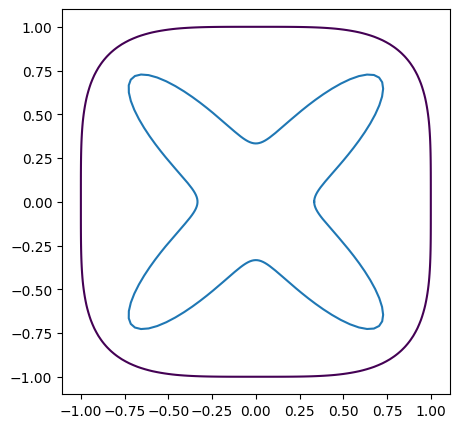

In [70]:
R=1.1
xs, ys = np.meshgrid(np.linspace(-R,R,100), np.linspace(-R,R,100))
zs = xs ** 4 + ys ** 4
ts = np.linspace(0,2*np.pi,200)
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('equal')
ax.contour(xs, ys, zs, levels=[1])
ax.plot(np.cos(ts)/(2 + np.cos(4*ts)), np.sin(ts)/(2 + np.cos(4*ts)))

Exercise 10

Here we calculate $\pi^{76}/e^{87}$ to $100$ decimal places (showing that the result is quite close to $1$).

In [26]:
mpmath.mp.dps = 100
print(mpmath.pi**76/mpmath.exp(87))

0.9994714642786526084896787713200013244848205348814720991942990611898142176107601532266629087441688956


Exercise 11

Here we attempt to simplify the expression $y=\sin(2x)\tan(2x)\frac{d^2}{dx^2}\log(\tan(x))$.

In [34]:
x = sp.symbols('x')
y = sp.sin(2*x) * sp.tan(2*x) * sp.diff(sp.log(sp.tan(x)),x,2)
y

(-(tan(x)**2 + 1)**2/tan(x)**2 + 2*tan(x)**2 + 2)*sin(2*x)*tan(2*x)

None of the following are very effective

In [35]:
display(sp.simplify(y))
display(sp.trigsimp(y))
display(sp.expand_trig(y))
display(sp.trigsimp(sp.expand_trig(y)))

(tan(x)**4 - 1)*sin(2*x)*tan(2*x)/tan(x)**2

(2*tan(x)**2 + 2 - 8/(1 - cos(4*x)))*sin(2*x)*tan(2*x)

4*(-(tan(x)**2 + 1)**2/tan(x)**2 + 2*tan(x)**2 + 2)*sin(x)*cos(x)*tan(x)/(1 - tan(x)**2)

4*(2*sin(x)**4/cos(x)**2 - 2*tan(x)**2 + 1)/(1 - 2*cos(x)**2)

However, sympy succeeds in showing that $y+4=0$, so we must have $y=-4$.

In [36]:
sp.simplify(y + 4)

0

We could also test this by evaluating $y$ at some random values of $x$.

In [37]:
[y.evalf(subs={x:a}) for a in [-0.1, 0.4, 1.2, 3.1]]

[-4.00000000000000, -4.00000000000000, -4.00000000000000, -4.00000000000000]